In [1]:
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

from roar import ALL_VEHICLES, MEASUREMENTS, VEHICLE_COLORS

sns.set_style("whitegrid")
sns.set_palette("husl")

In [ ]:
# FILE_PATH = "measure_logo_results.csv"
FILE_PATH = "vehicle_logo_results.csv"

In [3]:
df = pl.read_csv(FILE_PATH)

if FILE_PATH.startswith("measure_logo"):
    LOGO_GROUP = "measure"
    idx2name = {idx: measure for idx, measure in enumerate(MEASUREMENTS)}
    SPLIT_ORDER = MEASUREMENTS
    SPLIT_PALETTE = None
elif FILE_PATH.startswith("vehicle_logo"):
    LOGO_GROUP = "vehicle"
    idx2name = {idx: vehicle for idx, vehicle in enumerate(ALL_VEHICLES)}
    SPLIT_ORDER = ALL_VEHICLES
    SPLIT_PALETTE = VEHICLE_COLORS

In [ ]:
df.sort("mean_test_weighted_f1", descending=True).select(
    ["mean_test_weighted_f1", "model", "param_feature_selector__feature_set"]
).head(10)

mean_test_weighted_f1,model,param_feature_selector__feature_set
f64,str,str
0.842974,"""TabPFN""","""cleaned_invariant+speed"""
0.835003,"""TabPFN""","""cleaned_invariant+speed"""
0.831105,"""LogisticRegression_PCA""","""invariant"""
0.825267,"""TabPFN""","""cleaned_invariant+speed"""
0.821907,"""TabPFN""","""cleaned_invariant"""
0.816431,"""TabPFN""","""cleaned"""
0.812535,"""TabPFN""","""basic"""
0.812534,"""TabPFN""","""cleaned"""
0.811071,"""LogisticRegression_PCA""","""invariant"""


## Feature Set

In [32]:
best_models_f1 = (
    df.sort("mean_test_weighted_f1", descending=True)
    .unique(subset=["model", "param_feature_selector__feature_set"], keep="first")
    .select(
        pl.col("model"),
        pl.col("param_feature_selector__feature_set"),
        pl.col(r"^split\d+_test_weighted_f1$"),
    )
    .unpivot(
        index=["model", "param_feature_selector__feature_set"],
        variable_name="split",
        value_name="score",
    )
    .with_columns(
        pl.lit("weighted_f1").alias("metric"),
    )
)

best_models_acc = (
    df.sort("mean_test_weighted_f1", descending=True)
    .unique(subset=["model", "param_feature_selector__feature_set"], keep="first")
    .select(
        pl.col("model"),
        pl.col("param_feature_selector__feature_set"),
        pl.col(r"^split\d+_test_acc$"),
    )
    .unpivot(
        index=["model", "param_feature_selector__feature_set"],
        variable_name="split",
        value_name="score",
    )
    .with_columns(
        pl.lit("accuracy").alias("metric"),
    )
)

all_metrics = (
    pl.concat([best_models_f1, best_models_acc])
    .with_columns(pl.col("split").str.extract(r"(\d+)").cast(pl.Int64).alias("split"))
    .with_columns(pl.col("split").replace_strict(idx2name).alias("leave_out_group"))
)

In [33]:
model_name_mapping = {
    "DummyClassifier": "Dummy",
    "LogisticRegression_PCA": "PCA+LR",
    "SVC": "SVC",
    "RandomForest": "RF",
    "XGBoost": "XGB",
    "LightGBM": "LGBM",
    "TabPFN": "TabPFN",
}

MODEL_ORDER = [v for v in model_name_mapping.values()]

all_metrics = all_metrics.with_columns(
    pl.col("model").replace_strict(model_name_mapping).alias("model")
)
all_metrics

model,param_feature_selector__feature_set,split,score,metric,leave_out_group
str,str,i64,f64,str,str
"""SVC""","""cleaned_invariant+speed""",0,0.584,"""weighted_f1""","""meas1"""
"""LGBM""","""invariant""",0,0.876029,"""weighted_f1""","""meas1"""
"""LGBM""","""cleaned_invariant+speed""",0,0.873143,"""weighted_f1""","""meas1"""
"""XGB""","""cleaned_invariant""",0,0.873143,"""weighted_f1""","""meas1"""
"""LGBM""","""cleaned""",0,0.801096,"""weighted_f1""","""meas1"""
…,…,…,…,…,…
"""PCA+LR""","""cleaned_invariant""",5,1.0,"""accuracy""","""meas6"""
"""RF""","""cleaned+speed""",5,0.904762,"""accuracy""","""meas6"""
"""PCA+LR""","""cleaned+speed""",5,1.0,"""accuracy""","""meas6"""


In [34]:
feature_set_order = [
    "basic",
    "cleaned",
    "cleaned+speed",
    "invariant",
    "cleaned_invariant",
    "cleaned_invariant+speed",
]

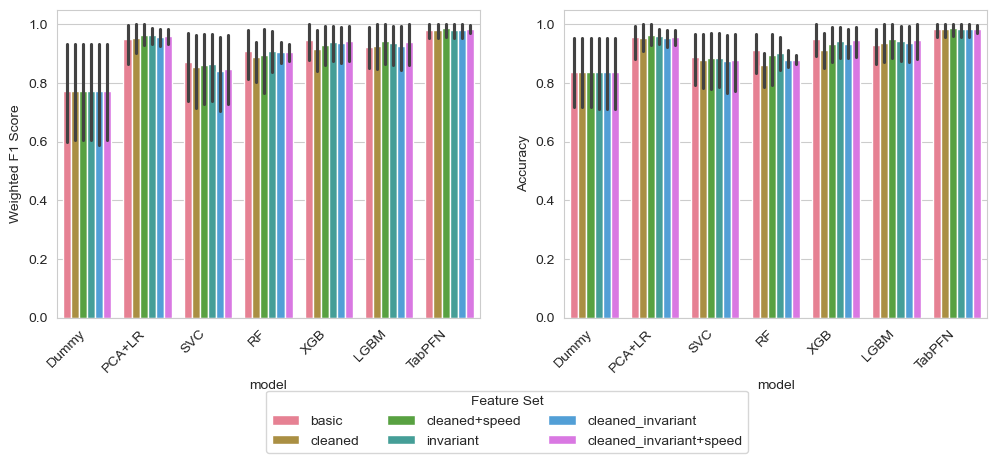

In [35]:
# 1. Mean F1 Score Comparison by Model and Feature Set
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=all_metrics.filter(pl.col("metric") == "weighted_f1").to_pandas(),
    x="model",
    y="score",
    hue="param_feature_selector__feature_set",
    hue_order=feature_set_order,
    order=MODEL_ORDER,
    ax=ax[0],
)
ax[0].set_ylabel("Weighted F1 Score")

sns.barplot(
    data=all_metrics.filter(pl.col("metric") == "accuracy").to_pandas(),
    x="model",
    y="score",
    hue="param_feature_selector__feature_set",
    hue_order=feature_set_order,
    order=MODEL_ORDER,
    ax=ax[1],
)
ax[1].set_ylabel("Accuracy")

# Move legend to the middle of the figure
handles, labels = ax[0].get_legend_handles_labels()
# remove individual legends if they exist
if ax[0].get_legend() is not None:
    ax[0].get_legend().remove()
if ax[1].get_legend() is not None:
    ax[1].get_legend().remove()
# place a single legend in the middle of the figure
fig.legend(handles, labels, loc="center", bbox_to_anchor=(0.5, -0.15), title="Feature Set", ncol=3)

# Rotate x-axis labels by 45 degrees
for axis in ax:
    axis.tick_params(axis="x", rotation=45)
    # Optional: align labels to the right for better readability
    for label in axis.get_xticklabels():
        label.set_ha("right")

### Feature Set Wins

In [36]:
models = ["log_reg", "lgbm", "rf", "svc", "tabpfn", "xgb"]
models_name_mapping = {
    "log_reg": "PCA+LR",
    "lgbm": "LGBM",
    "rf": "RF",
    "svc": "SVC",
    "tabpfn": "TabPFN",
    "xgb": "XGB",
}

res = []
for model in models:
    model_df = pl.read_csv(f"{model}_logo_{LOGO_GROUP}_results.csv")
    model_df = (
        model_df.group_by(pl.col("^param_.*$").exclude("param_feature_selector__feature_set"))
        .agg([pl.col("param_feature_selector__feature_set"), pl.col("mean_test_weighted_f1")])
        .with_columns(
            # Find the max f1 score in each group
            pl.col("mean_test_weighted_f1").list.max().alias("max_f1")
        )
        .explode(["param_feature_selector__feature_set", "mean_test_weighted_f1"])
        .with_columns(
            # Mark winners (feature sets with the max f1 score)
            (pl.col("mean_test_weighted_f1") == pl.col("max_f1")).alias("is_winner")
        )
        .filter(pl.col("is_winner"))
        .group_by("param_feature_selector__feature_set")
        .agg(pl.len().alias("wins"))
        .with_columns(pl.lit(model).alias("model"))
    )
    res.append(model_df)
final_df = pl.concat(res).with_columns(
    pl.col("model").replace_strict(models_name_mapping).alias("model")
)
final_df

param_feature_selector__feature_set,wins,model
str,u32,str
"""basic""",62,"""PCA+LR"""
"""cleaned_invariant""",13,"""PCA+LR"""
"""cleaned""",13,"""PCA+LR"""
"""cleaned_invariant+speed""",41,"""PCA+LR"""
"""invariant""",22,"""PCA+LR"""
…,…,…
"""cleaned_invariant""",90,"""XGB"""
"""cleaned""",29,"""XGB"""
"""cleaned+speed""",37,"""XGB"""


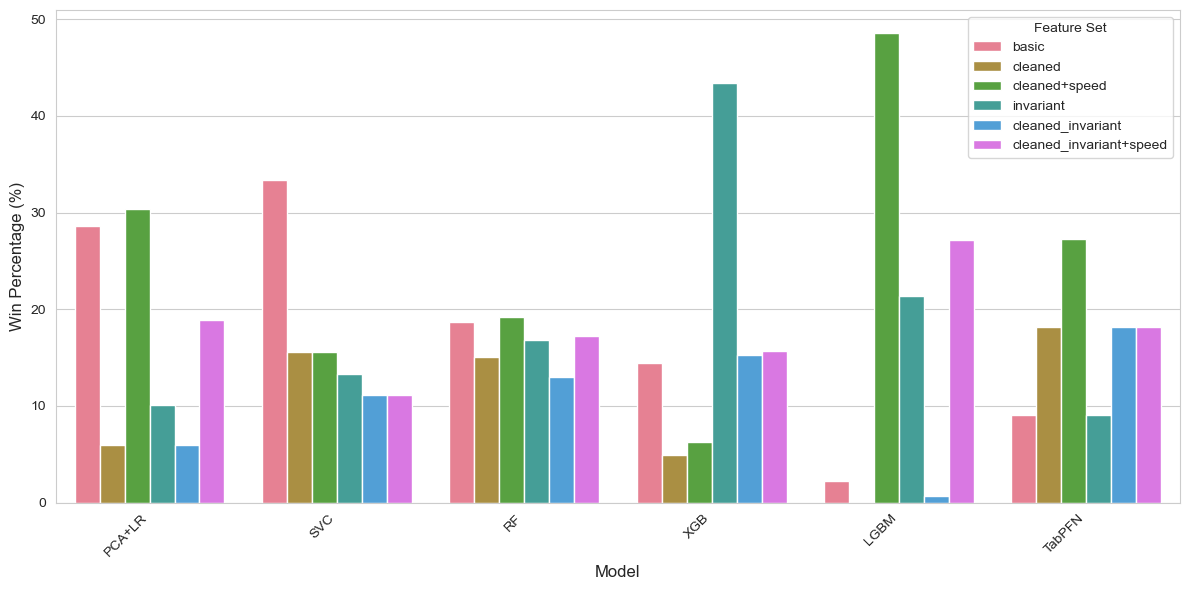

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to proportions within each model
wins_prop = final_df.with_columns(
    pl.col("wins").sum().over("model").alias("total_wins_per_model")
).with_columns((pl.col("wins") / pl.col("total_wins_per_model") * 100).alias("win_percentage"))

# Convert to pandas only for plotting
plot_df = wins_prop.select(
    ["param_feature_selector__feature_set", "model", "win_percentage"]
).to_pandas()

# Create barplot
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x="model",
    y="win_percentage",
    hue="param_feature_selector__feature_set",
    order=MODEL_ORDER[1:],
    hue_order=feature_set_order,
    ax=ax,
)

ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Win Percentage (%)", fontsize=12)
ax.legend(title="Feature Set")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Splitwise Results

In [38]:
# Plot the different splits

best_models_f1 = (
    df.sort("mean_test_weighted_f1", descending=True)
    .unique(subset=["model"], keep="first")
    .select(
        pl.col("model"),
        pl.col("param_feature_selector__feature_set"),
        pl.col(r"^split\d+_test_weighted_f1$"),
    )
    .unpivot(
        index=["model", "param_feature_selector__feature_set"],
        variable_name="split",
        value_name="score",
    )
    .with_columns(
        pl.lit("weighted_f1").alias("metric"),
    )
)

best_models_acc = (
    df.sort("mean_test_weighted_f1", descending=True)
    .unique(subset=["model"], keep="first")
    .select(
        pl.col("model"),
        pl.col("param_feature_selector__feature_set"),
        pl.col(r"^split\d+_test_acc$"),
    )
    .unpivot(
        index=["model", "param_feature_selector__feature_set"],
        variable_name="split",
        value_name="score",
    )
    .with_columns(
        pl.lit("accuracy").alias("metric"),
    )
)


all_metrics_split = (
    pl.concat([best_models_f1, best_models_acc])
    .with_columns(
        pl.col("split").str.extract(r"(\d+)").cast(pl.Int64).alias("split"),
        pl.col("model").replace_strict(model_name_mapping).alias("model"),
    )
    .with_columns(pl.col("split").replace_strict(idx2name).alias("leave_out_group"))
)

In [39]:
all_metrics_split

model,param_feature_selector__feature_set,split,score,metric,leave_out_group
str,str,i64,f64,str,str
"""SVC""","""basic""",0,0.584,"""weighted_f1""","""meas1"""
"""Dummy""","""basic""",0,0.499512,"""weighted_f1""","""meas1"""
"""PCA+LR""","""cleaned+speed""",0,0.895559,"""weighted_f1""","""meas1"""
"""TabPFN""","""cleaned+speed""",0,0.917353,"""weighted_f1""","""meas1"""
"""LGBM""","""cleaned+speed""",0,0.895559,"""weighted_f1""","""meas1"""
…,…,…,…,…,…
"""Dummy""","""basic""",5,1.0,"""accuracy""","""meas6"""
"""LGBM""","""cleaned+speed""",5,1.0,"""accuracy""","""meas6"""
"""XGB""","""basic""",5,1.0,"""accuracy""","""meas6"""


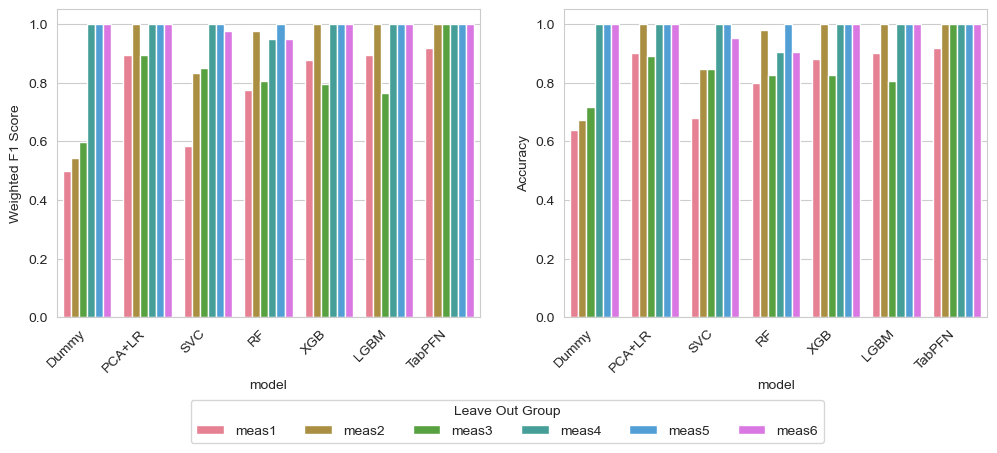

In [40]:
# 1. Mean F1 Score Comparison by Model and Feature Set
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=all_metrics_split.filter(pl.col("metric") == "weighted_f1").to_pandas(),
    x="model",
    y="score",
    hue="leave_out_group",
    order=MODEL_ORDER,
    hue_order=SPLIT_ORDER,
    palette=SPLIT_PALETTE,
    ax=ax[0],
)
ax[0].set_ylabel("Weighted F1 Score")

sns.barplot(
    data=all_metrics_split.filter(pl.col("metric") == "accuracy").to_pandas(),
    x="model",
    y="score",
    hue="leave_out_group",
    order=MODEL_ORDER,
    hue_order=SPLIT_ORDER,
    palette=SPLIT_PALETTE,
    ax=ax[1],
)
ax[1].set_ylabel("Accuracy")

# Move legend to the middle of the figure
handles, labels = ax[0].get_legend_handles_labels()
# remove individual legends if they exist
if ax[0].get_legend() is not None:
    ax[0].get_legend().remove()
if ax[1].get_legend() is not None:
    ax[1].get_legend().remove()
# place a single legend in the middle of the figure
fig.legend(
    handles,
    labels,
    loc="center",
    bbox_to_anchor=(0.5, -0.15),
    title="Leave Out Group",
    ncol=len(SPLIT_ORDER),
)

# Rotate x-axis labels by 45 degrees
for axis in ax:
    axis.tick_params(axis="x", rotation=45)
    # Optional: align labels to the right for better readability
    for label in axis.get_xticklabels():
        label.set_ha("right")